In [ ]:
def read_csv_safely(path):
    for enc in ["utf-8-sig", "utf-8", "cp949", "euc-kr"]:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"[OK] {path.name} | enc={enc} | shape={df.shape}")
            return df
        except Exception as e:
            print(f"[WARN] {enc}: {e}")

    raise ValueError(f"읽기 실패: {path}")


# 텍스트
df_text = read_csv_safely(TEXT_CSV)

# 이미지 (원본 읽은 뒤 바로 수정)
df_image_fixed = read_csv_safely(IMAGE_CSV)

df_image_fixed["image_url"] = (
    df_image_fixed["image_url"]
    .astype(str)
    .str.replace("w80_blur", "w800", regex=False)
)

# 확인
print(f"\ndf_text : {df_text.shape}")
print(f"df_image_fixed : {df_image_fixed.shape}")

display(df_text.head(2))
display(df_image_fixed.head(5))

# blur 남았는지 확인
print(
    df_image_fixed["image_url"]
    .str.contains("w80_blur", case=False, na=False)
    .sum()
)

In [ ]:
##텍스트 전처리 함수
def clean_paragraph(text: str) -> str:
    """단락 1개 정제"""
    if not text or pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("\u200b", "")          # zero-width space 제거
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def is_meaningful(text: str, min_chars: int = 20) -> bool:
    return len(text) >= min_chars

def split_into_paragraphs(full_text: str):
    """
    \\n\\n 기준 분리 → 정제 → 빈 단락 제거
    반환: [(paragraph_index, text), ...]
    paragraph_index 는 df_image_fixed 의 paragraph_index 와 대응
    """
    raw_paras = str(full_text).split("\n\n")
    result = []
    for i, para in enumerate(raw_paras):
        cleaned = clean_paragraph(para)
        if is_meaningful(cleaned):
            result.append((i, cleaned))
    return result


## 청킹

In [ ]:
chunk_rows = []

for _, post in df_text.iterrows():
    paragraphs = split_into_paragraphs(post["full_text"])
    for para_idx, para_text in paragraphs:
        chunk_rows.append({
            "post_id":         post["post_id"],
            "title":           post["title"],
            "url":             post["url"],
            "date":            post["date"],
            "blogger_id":      post["blogger_id"],
            "cej_stage":       post["cej_stage"],
            "keyword":         post["keyword"],
            "paragraph_index": para_idx,        # df_image_fixed 와 매칭 키
            "chunk_text":      para_text,
            "chunk_len":       len(para_text),
            "text_length":     post["text_length"],
            "image_count":     post["image_count"],
        })

chunk_df = pd.DataFrame(chunk_rows)

print(f"원본 게시글:        {df_text['post_id'].nunique()} 개")
print(f"생성된 chunk:       {len(chunk_df)} 개")
print(f"게시글당 평균 chunk: {len(chunk_df) / df_text['post_id'].nunique():.1f} 개")
print("\nchunk_len 분포")
display(chunk_df["chunk_len"].describe())
display(chunk_df.head(5))



In [ ]:
post_images = defaultdict(list)
for df_img_idx, row in df_image_fixed.iterrows():
    post_images[row["post_id"]].append({
        "df_img_idx":      df_img_idx,
        "image_url":       row["image_url"],
        "image_index":     row["image_index"],
        "paragraph_index": row["paragraph_index"],
    })

print(f"post 수:              {len(post_images)}")
print(f"post당 평균 이미지 수: {df_image_fixed.shape[0] / len(post_images):.1f} 장")

post 수:              448
post당 평균 이미지 수: 11.0 장


In [ ]:
def get_text_quality(text):
    if pd.isna(text) or len(str(text).strip()) == 0:
        return "empty"
    if len(str(text).strip()) < 15:
        return "too_short"
    return "usable"

# 임베딩용 텍스트: 제목 + chunk 본문 (400자 제한)
chunk_df["text_for_emb"] = (
    chunk_df["title"].apply(clean_paragraph)
    + " "
    + chunk_df["chunk_text"]
).str[:400]

chunk_df["text_quality"] = chunk_df["text_for_emb"].apply(get_text_quality)

analysis_df = chunk_df[chunk_df["text_quality"] == "usable"].copy().reset_index(drop=True)

print(f"analysis_df (usable chunk 전체): {analysis_df.shape}")
print("\ntext_quality 분포")
display(chunk_df["text_quality"].value_counts())
display(analysis_df[["post_id", "paragraph_index", "cej_stage", "chunk_len", "text_for_emb"]].head(8))



In [ ]:
chunk_df.to_csv(OUTPUT_DIR / "blog_chunk_all.csv",      index=False, encoding="utf-8-sig")
analysis_df.to_csv(OUTPUT_DIR / "blog_analysis_base.csv", index=False, encoding="utf-8-sig")
print("저장 완료")
print(f"  전체 chunk:  {len(chunk_df)}")
print(f"  분석 대상:   {len(analysis_df)}")


# ── [셀 8] GPU 확인 ───────────────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")

저장 완료
  전체 chunk:  13718
  분석 대상:   13718
device: cuda
GPU: Tesla T4
VRAM: 14.56 GB


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')
chunk_df = pd.read_csv(OUTPUT_DIR / "blog_chunk_all.csv")
analysis_df = pd.read_csv(OUTPUT_DIR / "blog_analysis_base.csv")

In [ ]:
!pip install -q -U "transformers>=4.57.0" "accelerate>=1.12.0" "qwen-vl-utils>=0.0.14" tqdm einops
!rm -rf /content/Qwen3-VL-Embedding
!git clone -q https://github.com/QwenLM/Qwen3-VL-Embedding.git /content/Qwen3-VL-Embedding
print("설치 완료")

In [ ]:
sys.path.insert(0, "/content/Qwen3-VL-Embedding")
from src.models.qwen3_vl_embedding import Qwen3VLEmbedder

MODEL_NAME  = "Qwen/Qwen3-VL-Embedding-2B"
major, _    = torch.cuda.get_device_capability(0)
TORCH_DTYPE = torch.bfloat16 if major >= 8 else torch.float16

gc.collect()
torch.cuda.empty_cache()

qwen_model = Qwen3VLEmbedder(
    model_name_or_path=MODEL_NAME,
    torch_dtype=TORCH_DTYPE,
    attn_implementation="sdpa",
    max_pixels=512 * 512,
)
print("모델 로딩 완료")

## 임베딩 유틸 함수

In [ ]:
def to_numpy_norm(embs):
    """텐서 or ndarray → float32 L2 정규화 ndarray"""
    if hasattr(embs, "detach"):
        embs = embs.detach().cpu().float().numpy()
    else:
        embs = np.asarray(embs, dtype=np.float32)
    norms = np.linalg.norm(embs, axis=1, keepdims=True)
    return embs / np.maximum(norms, 1e-12)


def encode_texts(df, col="text_for_emb", batch_size=8):
    """DataFrame 의 텍스트 컬럼을 배치 임베딩"""
    valid_idx, failed_idx, skipped_idx, all_embs = [], [], [], []

    for start in tqdm(range(0, len(df), batch_size), desc="Text embedding"):
        batch  = df.iloc[start:start + batch_size]
        inputs, bidx = [], []

        for idx, row in batch.iterrows():
            txt = str(row[col]).strip()
            if not txt:
                skipped_idx.append(idx)
                continue
            inputs.append({"text": txt})
            bidx.append(idx)

        if not inputs:
            continue

        try:
            with torch.no_grad():
                embs = qwen_model.process(inputs)
            all_embs.append(to_numpy_norm(embs))
            valid_idx.extend(bidx)
        except RuntimeError as e:
            print(f"[ERR] batch {start}: {e}")
            failed_idx.extend(bidx)
            torch.cuda.empty_cache()
            gc.collect()

    if not all_embs:
        return valid_idx, np.empty((0, 0), dtype=np.float32), failed_idx, skipped_idx

    return valid_idx, np.vstack(all_embs), failed_idx, skipped_idx


def encode_images_all(df_img, url_col="image_url", batch_size=2):
    """df_image_fixed 의 모든 이미지를 개별 임베딩"""
    valid_idx, failed_idx, all_embs = [], [], []

    for start in tqdm(range(0, len(df_img), batch_size), desc="Image embedding"):
        batch  = df_img.iloc[start:start + batch_size]
        inputs, bidx = [], []

        for idx, row in batch.iterrows():
            url = str(row[url_col]).strip()
            if not url or url == "nan":
                failed_idx.append(idx)
                continue
            inputs.append({"image": url})
            bidx.append(idx)

        if not inputs:
            continue

        try:
            with torch.no_grad():
                embs = qwen_model.process(inputs)
            all_embs.append(to_numpy_norm(embs))
            valid_idx.extend(bidx)
        except RuntimeError as e:
            print(f"[ERR] batch {start}: {e}")
            failed_idx.extend(bidx)
            torch.cuda.empty_cache()
            gc.collect()

    if not all_embs:
        return valid_idx, np.empty((0, 0), dtype=np.float32), failed_idx

    return valid_idx, np.vstack(all_embs), failed_idx

## 텍스트, 이미지 임베딩

In [ ]:
text_valid_idx, text_embs, text_failed, text_skipped = encode_texts(analysis_df, batch_size=8)

print(f"텍스트 valid={len(text_valid_idx)}  failed={len(text_failed)}  skipped={len(text_skipped)}")
print(f"text_embs shape: {text_embs.shape}")

In [ ]:
img_valid_idx, img_embs_all, img_failed = encode_images_all(df_image_fixed, batch_size=2)

# df_image_fixed 행 index → 임베딩 배열 위치 매핑
img_pos_map = {idx: pos for pos, idx in enumerate(img_valid_idx)}

print(f"이미지 전체 임베딩: {img_embs_all.shape}")
print(f"이미지 failed:      {len(img_failed)}")

In [ ]:
np.save(OUTPUT_DIR / "text_embs.npy",      text_embs)
np.save(OUTPUT_DIR / "img_embs_all.npy",   img_embs_all)
np.save(OUTPUT_DIR / "text_valid_idx.npy", np.array(text_valid_idx))
np.save(OUTPUT_DIR / "img_valid_idx.npy",  np.array(img_valid_idx))
print("임베딩 캐시 저장 완료")

임베딩 캐시 저장 완료


In [ ]:
# ── [셀 15] 샘플 유사도 확인 (threshold 조정용) ────────────────────────────────
text_pos_map = {idx: pos for pos, idx in enumerate(text_valid_idx)}

# NOTE: reset_index 하지 않아야 원본 index 가 text_pos_map 키와 일치
sample_df = analysis_df.sample(n=8, random_state=42)

sample_t_embs = np.vstack([
    text_embs[text_pos_map[idx]]
    for idx in sample_df.index
    if idx in text_pos_map
])

sample_i_urls, sample_i_embs = [], []
for _, row in sample_df.iterrows():
    pid    = row["post_id"]
    cands  = [c for c in post_images.get(pid, []) if c["df_img_idx"] in img_pos_map]
    if cands:
        c = cands[0]
        sample_i_urls.append(c["image_url"])
        sample_i_embs.append(img_embs_all[img_pos_map[c["df_img_idx"]]])
    else:
        sample_i_urls.append(None)
        sample_i_embs.append(np.zeros(text_embs.shape[1], dtype=np.float32))

sample_i_embs = np.vstack(sample_i_embs)
diag = np.diag(sample_t_embs @ sample_i_embs.T)

print("샘플 텍스트-이미지 유사도:", np.round(diag, 4))
display(
    sample_df[["post_id", "paragraph_index", "cej_stage", "chunk_len"]]
    .assign(image_url=sample_i_urls, sim=diag.round(4))
)


In [ ]:
# img_pos_map 재생성 및 검증
img_pos_map = {idx: pos for pos, idx in enumerate(img_valid_idx)}

# 검증
max_pos = max(img_pos_map.values())
print(f"img_embs_all 크기:       {img_embs_all.shape[0]}")
print(f"img_pos_map 최대 pos값:  {max_pos}")
print(f"img_valid_idx 길이:      {len(img_valid_idx)}")

# 혹시 범위 초과 항목 있으면 필터링
img_pos_map = {
    idx: pos for idx, pos in img_pos_map.items()
    if pos < img_embs_all.shape[0]
}
print(f"필터링 후 유효 img_pos_map: {len(img_pos_map)}")

img_embs_all 크기:       4920
img_pos_map 최대 pos값:  4937
img_valid_idx 길이:      4938
필터링 후 유효 img_pos_map: 4920


In [ ]:
# ── [셀 16] chunk ↔ image 매칭 ────────────────────────────────────────────────
SIM_THRESHOLD = 0.15   # 샘플 확인 후 조정

matched_rows = []

for chunk_idx in tqdm(text_valid_idx, desc="chunk-image matching"):
    row     = analysis_df.loc[chunk_idx]
    post_id = row["post_id"]
    t_emb   = text_embs[text_pos_map[chunk_idx]]   # (D,)

    candidates  = post_images.get(post_id, [])
    valid_cands = [c for c in candidates if c["df_img_idx"] in img_pos_map]
    if not valid_cands:
        continue

    cand_embs = np.vstack([
        img_embs_all[img_pos_map[c["df_img_idx"]]] for c in valid_cands
    ])  # (N_img, D)

    sims = cand_embs @ t_emb  # cosine similarity (L2 정규화 완료)

    for c, sim in zip(valid_cands, sims):
        if float(sim) >= SIM_THRESHOLD:
            matched_rows.append({
                "chunk_idx":       chunk_idx,
                "post_id":         post_id,
                "paragraph_index": row["paragraph_index"],
                "cej_stage":       row["cej_stage"],
                "keyword":         row["keyword"],
                "chunk_text":      row["chunk_text"],
                "text_for_emb":    row["text_for_emb"],
                "text_length":     row["text_length"],
                "image_url":       c["image_url"],
                "image_index":     c["image_index"],
                "img_para_idx":    c["paragraph_index"],
                "chunk_image_sim": float(sim),
                "df_img_idx":      c["df_img_idx"],
            })

matched_df = pd.DataFrame(matched_rows)

print(f"유사도 {SIM_THRESHOLD} 이상 chunk-image 페어: {len(matched_df)}")
print(f"관련 chunk 수:  {matched_df['chunk_idx'].nunique()}")
print(f"관련 이미지 수: {matched_df['df_img_idx'].nunique()}")
print("\nchunk_image_sim 분포")
display(matched_df["chunk_image_sim"].describe())


In [ ]:
# threshold별 chunk당 평균 이미지 수 변화
for thr in [0.15, 0.20, 0.25, 0.30, 0.35]:
    sub = matched_df[matched_df["chunk_image_sim"] >= thr]
    n_chunks = sub["chunk_idx"].nunique()
    n_pairs  = len(sub)
    avg_img  = n_pairs / n_chunks if n_chunks > 0 else 0
    print(f"thr={thr:.2f} → 페어 {n_pairs:6d}개 | chunk {n_chunks:5d}개 | chunk당 평균 {avg_img:.1f}장")

thr=0.15 → 페어 129464개 | chunk 12809개 | chunk당 평균 10.1장
thr=0.20 → 페어  96582개 | chunk 12352개 | chunk당 평균 7.8장
thr=0.25 → 페어  60325개 | chunk 11085개 | chunk당 평균 5.4장
thr=0.30 → 페어  32703개 | chunk  9135개 | chunk당 평균 3.6장
thr=0.35 → 페어  14443개 | chunk  6193개 | chunk당 평균 2.3장


In [ ]:
SIM_THRESHOLD = 0.25

matched_df_filtered = matched_df[matched_df["chunk_image_sim"] >= SIM_THRESHOLD].copy()

print(f"기존: {len(matched_df)}")
print(f"필터링 후: {len(matched_df_filtered)}")
print(f"\nchunk_image_sim 분포")
display(matched_df_filtered["chunk_image_sim"].describe())

기존: 129464
필터링 후: 60325

chunk_image_sim 분포


,chunk_image_sim
count,60325.000000
mean,0.318258
std,0.055596
min,0.250001
25%,0.275090
50%,0.305458
75%,0.347373
max,0.666911


In [ ]:
matched_df = matched_df_filtered.copy()

matched_df.to_csv(OUTPUT_DIR / "blog_matched_pairs.csv", index=False, encoding="utf-8-sig")
print(f"저장 완료: {len(matched_df)} 페어")
print(f"관련 chunk 수:  {matched_df['chunk_idx'].nunique()}")
print(f"관련 이미지 수: {matched_df['df_img_idx'].nunique()}")

저장 완료: 60325 페어
관련 chunk 수:  11085
관련 이미지 수: 2801


## 텍스트 군집화 → CEJ 매핑 → 이미지 군집화

In [ ]:
!pip install -q umap-learn hdbscan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path
from collections import Counter

import umap
import hdbscan
from sklearn.preprocessing import normalize

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# !apt-get -qq install fonts-nanum  ← 이미 설치됨, 주석처리 가능

# fm._rebuild() 대신 아래로 교체
fm.fontManager.__init__()

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

OUTPUT_DIR = Path("/content/drive/MyDrive/[LG전자 산학] Team 재훈/Team/희원/분석용_데이터")

print("폰트 설정 완료")

폰트 설정 완료


In [ ]:
# ── [셀 20] 임베딩 & 메타데이터 로딩 ─────────────────────────────────────────
# 이전 세션에서 저장한 캐시 로딩
text_embs      = np.load(OUTPUT_DIR / "text_embs.npy")
text_valid_idx = np.load(OUTPUT_DIR / "text_valid_idx.npy").tolist()
img_embs_all   = np.load(OUTPUT_DIR / "img_embs_all.npy")
img_valid_idx  = np.load(OUTPUT_DIR / "img_valid_idx.npy").tolist()

analysis_df    = pd.read_csv(OUTPUT_DIR / "blog_analysis_base.csv", encoding="utf-8-sig")
matched_df     = pd.read_csv(OUTPUT_DIR / "blog_matched_pairs.csv",  encoding="utf-8-sig")

img_pos_map  = {idx: pos for pos, idx in enumerate(img_valid_idx)}
text_pos_map = {idx: pos for pos, idx in enumerate(text_valid_idx)}

print(f"text_embs : {text_embs.shape}")
print(f"img_embs  : {img_embs_all.shape}")
print(f"analysis_df: {analysis_df.shape}")
print(f"matched_df : {matched_df.shape}")


text_embs : (13718, 2048)
img_embs  : (4920, 2048)
analysis_df: (13718, 14)
matched_df : (60325, 13)


In [ ]:
# ── [셀 21] 군집화 대상 임베딩 준비 ──────────────────────────────────────────
# text_valid_idx 순서대로 analysis_df 행을 정렬
cluster_df = analysis_df.loc[text_valid_idx].copy()
cluster_df["emb_pos"] = range(len(text_valid_idx))  # text_embs 행 위치
cluster_embs = text_embs  # (N, 2048)

print(f"군집화 대상: {cluster_embs.shape}")

군집화 대상: (13718, 2048)


In [ ]:
# 셀 22: 제목 임베딩 생성
# =============================================================================
title_df = analysis_df.drop_duplicates("post_id")[["post_id", "title"]].copy()
title_df["title_clean"] = title_df["title"].apply(clean_paragraph).str[:200]
title_df = title_df.reset_index(drop=True)

title_valid_idx, title_embs, title_failed, _ = encode_texts(
    title_df, col="title_clean", batch_size=16
)
title_pos_map = {idx: pos for pos, idx in enumerate(title_valid_idx)}

# post_id → 제목 임베딩 dict
post_title_emb = dict(zip(
    title_df.loc[title_valid_idx, "post_id"],
    [title_embs[title_pos_map[i]] for i in title_valid_idx]
))
print(f"제목 임베딩 완료: {len(post_title_emb)} 개 post")

In [ ]:
# 셀 23: chunk별 제목-유사도 계산
# =============================================================================
cluster_df = analysis_df.loc[text_valid_idx].copy()
cluster_df["emb_pos"] = range(len(text_valid_idx))

title_sims = []
for idx in text_valid_idx:
    row   = analysis_df.loc[idx]
    pid   = row["post_id"]
    t_emb = text_embs[text_pos_map[idx]]

    if pid in post_title_emb:
        sim = float(post_title_emb[pid] @ t_emb)
    else:
        sim = 0.0
    title_sims.append(sim)

cluster_df["title_sim"] = title_sims

print("title_sim 분포")
display(cluster_df["title_sim"].describe())


title_sim 분포


,title_sim
count,13718.000000
mean,0.900581
std,0.058716
min,0.562286
25%,0.869518
50%,0.913205
75%,0.944237
max,0.997781


In [ ]:
TOP_N = 3  # post당 title과 가장 유사한 chunk 상위 3개

filtered_df = (
    cluster_df
    .sort_values("title_sim", ascending=False)
    .groupby("post_id")
    .head(TOP_N)
    .sort_index()
    .copy()
)

print(f"전체 chunk:      {len(cluster_df)}")
print(f"필터링 후:       {len(filtered_df)}")
print(f"평균 title_sim:  {filtered_df['title_sim'].mean():.4f}")
print(f"(전체 평균:      {cluster_df['title_sim'].mean():.4f})")

# 필터링된 chunk의 임베딩 추출
filtered_embs = np.vstack([
    text_embs[text_pos_map[idx]]
    for idx in filtered_df.index
    if idx in text_pos_map
])
print(f"\n군집화 대상 임베딩: {filtered_embs.shape}")


전체 chunk:      13718
필터링 후:       1392
평균 title_sim:  0.9472
(전체 평균:      0.9006)

군집화 대상 임베딩: (1392, 2048)


In [ ]:
print(f"post 수:              {cluster_df['post_id'].nunique()}")
print(f"post당 평균 chunk 수: {len(cluster_df) / cluster_df['post_id'].nunique():.1f}")
print(f"필터링 후 post 수:    {filtered_df['post_id'].nunique()}")
print(f"필터링 후 post당 평균:{len(filtered_df) / filtered_df['post_id'].nunique():.1f}")

post 수:              469
post당 평균 chunk 수: 29.2
필터링 후 post 수:    469
필터링 후 post당 평균:3.0


In [ ]:
# 셀 25: UMAP 차원 축소 (필터링된 임베딩으로)
# =============================================================================
import umap

reducer_cluster = umap.UMAP(
    n_components=20,
    n_neighbors=30,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
    verbose=True,
)
embs_20d_filtered = reducer_cluster.fit_transform(filtered_embs)
print(f"UMAP 20d 완료: {embs_20d_filtered.shape}")

reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
    verbose=True,
)
embs_2d_filtered = reducer_2d.fit_transform(filtered_embs)
print(f"UMAP 2d 완료: {embs_2d_filtered.shape}")

np.save(OUTPUT_DIR / "umap_20d_filtered.npy", embs_20d_filtered)
np.save(OUTPUT_DIR / "umap_2d_filtered.npy",  embs_2d_filtered)


In [ ]:
# =============================================================================
# 텍스트 HDBSCAN 군집화
# =============================================================================

import hdbscan
import pandas as pd

# -----------------------------------------------------------------------------
# HDBSCAN 파라미터 가이드
# -----------------------------------------------------------------------------
# min_cluster_size :
#   군집으로 인정할 최소 샘플 수
#   - 너무 작으면 군집 폭발
#   - 너무 크면 큰 덩어리로 뭉개짐
#
# min_samples :
#   core point 기준
#   - 클수록 noise 증가
#   - 보통 min_cluster_size보다 작게 설정
#
# cluster_selection_method :
#   "eom"  → 넓고 안정적인 군집
#   "leaf" → 더 촘촘하고 세밀한 군집
# -----------------------------------------------------------------------------

MIN_CLUSTER_SIZE = 30
MIN_SAMPLES      = 10

# =============================================================================
# HDBSCAN 모델 생성
# =============================================================================

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    cluster_selection_method="eom",
    metric="euclidean",   # UMAP 결과에는 보통 euclidean 사용
    prediction_data=True
)

# =============================================================================
# 군집화 수행
# =============================================================================

cluster_labels = clusterer.fit_predict(embs_20d_filtered)

# =============================================================================
# 군집 통계
# =============================================================================

n_clusters = len(set(cluster_labels)) - (
    1 if -1 in cluster_labels else 0
)

n_noise = (cluster_labels == -1).sum()

noise_ratio = n_noise / len(cluster_labels)

print(f"발견된 군집 수 : {n_clusters}")
print(f"노이즈 포인트 : {n_noise} ({noise_ratio:.1%})")

# =============================================================================
# 군집 분포 확인
# =============================================================================

cluster_dist = (
    pd.Series(cluster_labels)
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="count")
)

print("\n군집 분포 (noise=-1)\n")

display(cluster_dist)

# =============================================================================
# 결과 저장
# =============================================================================

filtered_df = filtered_df.copy()

filtered_df["cluster"] = cluster_labels

print("\ncluster 컬럼 추가 완료")
print(filtered_df[["cluster"]].head())

발견된 군집 수 : 11
노이즈 포인트 : 207 (14.9%)

군집 분포 (noise=-1)



,cluster,count
0,-1,207
1,0,57
2,1,34
3,2,45
4,3,44
5,4,39
6,5,431
7,6,143
8,7,150
9,8,63



cluster 컬럼 추가 완료
    cluster
11       10
13       10
14       10
37        2
38        2


Clusters : 11
Noise    : 207

Saved: /content/drive/MyDrive/[LG전자 산학] Team 재훈/Team/희원/분석용_데이터/umap_clusters_filtered.png


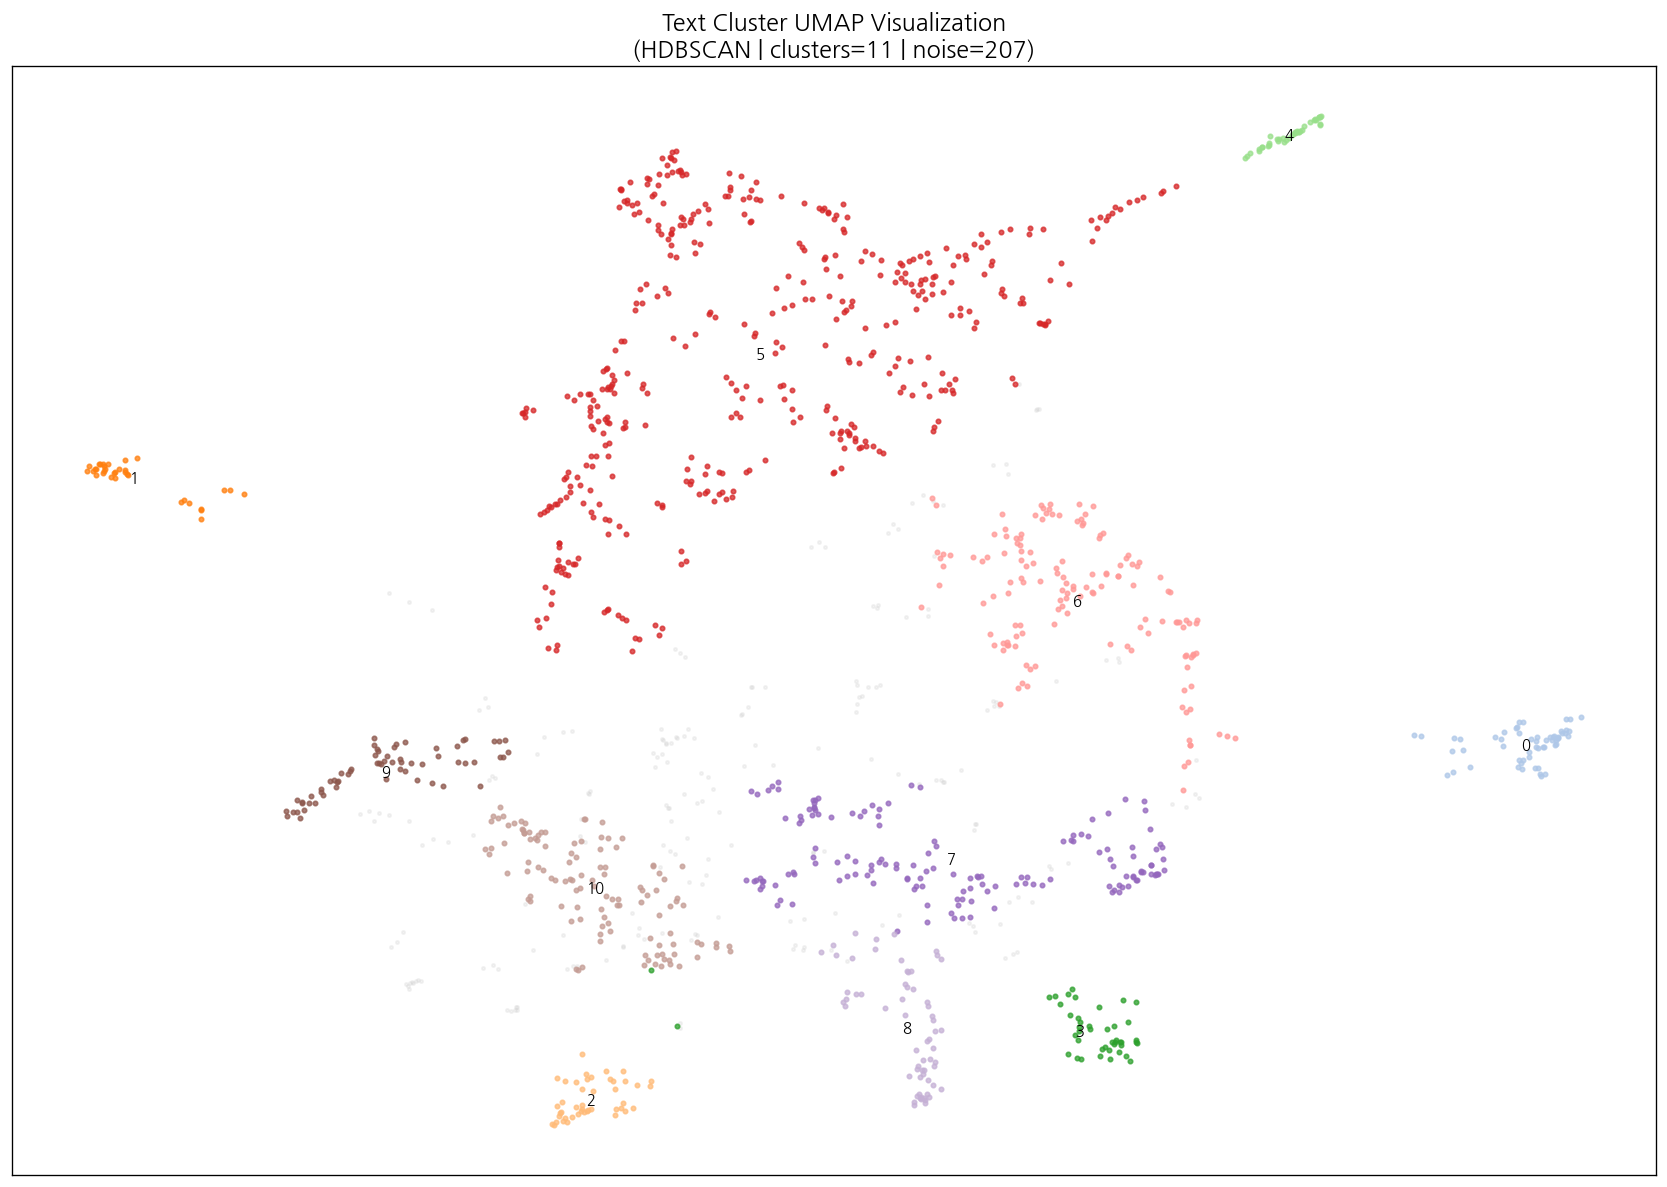

In [ ]:
# =============================================================================
# UMAP 2D Visualization (Cluster Check)
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------------------------------------------
# Cluster Info
# -----------------------------------------------------------------------------

unique_labels = sorted(set(cluster_labels))

n_clusters = len(unique_labels) - (
    1 if -1 in unique_labels else 0
)

n_noise = (cluster_labels == -1).sum()

print(f"Clusters : {n_clusters}")
print(f"Noise    : {n_noise}")

# =============================================================================
# Color Palette
# =============================================================================

cmap = plt.get_cmap("tab20")

colors = {
    cid: (
        "lightgray"
        if cid == -1
        else cmap(i % 20)
    )
    for i, cid in enumerate(unique_labels)
}

# =============================================================================
# Figure
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 10))

# =============================================================================
# Scatter Plot
# =============================================================================

for cid in unique_labels:

    mask = (cluster_labels == cid)

    label = (
        "noise"
        if cid == -1
        else f"cluster {cid}"
    )

    ax.scatter(
        embs_2d_filtered[mask, 0],
        embs_2d_filtered[mask, 1],

        c=[colors[cid]],

        s=4 if cid == -1 else 7,

        alpha=0.25 if cid == -1 else 0.75,

        label=label
    )

# =============================================================================
# Cluster Center Labels
# =============================================================================

for cid in unique_labels:

    if cid == -1:
        continue

    mask = (cluster_labels == cid)

    cx = embs_2d_filtered[mask, 0].mean()
    cy = embs_2d_filtered[mask, 1].mean()

    ax.text(
        cx,
        cy,
        str(cid),

        fontsize=9,
        fontweight="bold",

        ha="center",
        va="center"
    )

# =============================================================================
# Title
# =============================================================================

ax.set_title(
    f"Text Cluster UMAP Visualization\n"
    f"(HDBSCAN | clusters={n_clusters} | noise={n_noise})",
    fontsize=14
)

# Remove axis ticks
ax.set_xticks([])
ax.set_yticks([])

# =============================================================================
# Save
# =============================================================================

plt.tight_layout()

save_path = OUTPUT_DIR / "umap_clusters_filtered.png"

plt.savefig(
    save_path,
    dpi=150,
    bbox_inches="tight"
)

print(f"\nSaved: {save_path}")

plt.show()

In [ ]:
# =============================================================================
# 군집별 대표 텍스트 & 키워드 확인
# (군집 품질 점검용)
# =============================================================================

from collections import Counter

# =============================================================================
# cluster 대표 keyword 추출
# =============================================================================

def get_cluster_keywords(df, cluster_id, top_n=5):

    sub = df[df["cluster"] == cluster_id]

    kws = (
        sub["keyword"]
        .dropna()
        .str.split(",")
        .explode()
        .str.strip()
    )

    return Counter(kws).most_common(top_n)

# =============================================================================
# cluster 대표 text sample 추출
# =============================================================================

def get_cluster_samples(df, cluster_id, top_n=3):

    sub = df[df["cluster"] == cluster_id]

    # 너무 짧거나 긴 문장 제외
    sub = sub[
        (sub["chunk_len"] >= 50) &
        (sub["chunk_len"] <= 300)
    ]

    # 조건 만족 없으면 전체 사용
    if sub.empty:
        sub = df[df["cluster"] == cluster_id]

    return (
        sub["chunk_text"]
        .dropna()
        .head(top_n)
        .tolist()
    )

# =============================================================================
# 유효 cluster 목록
# =============================================================================

valid_cluster_ids = sorted([
    c
    for c in filtered_df["cluster"].unique()
    if c != -1
])

print(f"분석 대상 cluster 수: {len(valid_cluster_ids)}")

# =============================================================================
# cluster별 품질 확인
# =============================================================================

for cid in valid_cluster_ids:

    # -------------------------------------------------------------------------
    # cluster subset
    # -------------------------------------------------------------------------

    sub = filtered_df[filtered_df["cluster"] == cid]

    size = len(sub)

    # -------------------------------------------------------------------------
    # keyword
    # -------------------------------------------------------------------------

    kws = get_cluster_keywords(
        filtered_df,
        cid,
        top_n=5
    )

    # -------------------------------------------------------------------------
    # sample text
    # -------------------------------------------------------------------------

    samples = get_cluster_samples(
        filtered_df,
        cid,
        top_n=3
    )

    # -------------------------------------------------------------------------
    # CEJ 분포
    # -------------------------------------------------------------------------

    cej_dist = (
        sub["cej_stage"]
        .value_counts()
        .to_dict()
    )

    # =============================================================================
    # 출력
    # =============================================================================

    print("\n" + "=" * 70)
    print(f"Cluster {cid} (n={size})")
    print("=" * 70)

    print(f"CEJ 분포 : {cej_dist}")

    print(
        "키워드  :",
        [k for k, _ in kws]
    )

    print("\n[대표 텍스트]")

    for i, s in enumerate(samples[:2], start=1):

        s = str(s).replace("\n", " ")

        print(f"{i}. {s[:120]}...")

# =============================================================================
# noise 통계
# =============================================================================

noise_n = (filtered_df["cluster"] == -1).sum()

print("\n" + "=" * 70)
print(f"Noise(-1): {noise_n}개 chunk")
print("→ 군집화에서 제외된 데이터")
print("=" * 70)

분석 대상 cluster 수: 11

Cluster 0 (n=57)
CEJ 분포 : {'교체': 54, '관리': 3}
키워드  : ['LG냉장고 교체', '엘지냉장고 AS', '냉장고 교체 후기']

[대표 텍스트]
1. LG 냉장고 정수기는 정기적인 살균 케어와 청결 관리가 병행될 때 더 안심하고 사용할 수 있습니다. 바쁜 일상에서 직접 관리가 어렵다면 헬스케어 서비스를 통해 전문가의 도움을 받는 방법도 고려해 볼 만합니다....
2. 교체용 필터 등 소모품은 LG전자 소모품샵을 통해 구입하거나 고객센터 전문 상담사를 통해 안내받을 수 있습니다. 모델에 따라 교체 방법이 미세하게 다를 수 있다는 점을 유의하며, 기기 매뉴얼을 함께 참조하는 것이 정...

Cluster 1 (n=34)
CEJ 분포 : {'교체': 31, '관리': 3}
키워드  : ['LG냉장고 교체', 'LG냉장고 수리', '냉장고 교체 후기']

[대표 텍스트]
1. •안내에 따라 서비스센터를 통해 부품을 구매하거나 출장 교체 서비스를 신청할 수 있습니다....

Cluster 2 (n=45)
CEJ 분포 : {'관리': 42, '교체': 3}
키워드  : ['LG냉장고 수리', 'LG냉장고 고장', '엘지냉장고 AS', 'LG냉장고 교체']

[대표 텍스트]
1. 가전 기기는 정기적인 관리와 정확한 진단이 수명을 결정합니다. 특히 냉장고와 같이 24시간 가동되는 제품은 작은 에러라도 간과하지 않는 자세가 필요합니다. 만약 현재 기기 화면에 ER, CH, CL 등의 코드가 표시...

Cluster 3 (n=44)
CEJ 분포 : {'관리': 38, '교체': 6}
키워드  : ['LG냉장고 고장', 'LG냉장고 수리', '엘지냉장고 AS', 'LG냉장고 교체']

[대표 텍스트]
1. 저와 비슷한 고민을 하고 계신분들에게 조금이나마 도움이 되길 원하면서 기록을 남겨봅니다-*...

Cluster 4 (n=39)
CEJ 분포 : {'교체': 39}
키워드  : ['냉장고 바꿨어요']



In [ ]:
filtered_df.to_csv(OUTPUT_DIR / "blog_clustered.csv", index=False, encoding="utf-8-sig")
print(f"저장 완료: blog_clustered.csv ({len(filtered_df)} rows)")

In [ ]:
# =============================================================================
# 노이즈 제거
# =============================================================================

# -----------------------------------------------------------------------------
# HDBSCAN noise(-1)는 자동 제거
# 추가로 사람이 직접 확인 후
# 의미 없는 cluster를 수동 제거 가능
# -----------------------------------------------------------------------------

# 예시:
# MANUAL_NOISE = [3, 7]
# → cluster 3번, 7번 제거

MANUAL_NOISE = []

# =============================================================================
# 제거 대상 cluster
# =============================================================================

remove_clusters = set(MANUAL_NOISE) | {-1}

# =============================================================================
# clean dataframe 생성
# =============================================================================

clean_df = filtered_df[
    ~filtered_df["cluster"].isin(remove_clusters)
].copy()

# =============================================================================
# 통계 출력
# =============================================================================

total_n = len(filtered_df)

hdbscan_noise_n = (
    filtered_df["cluster"] == -1
).sum()

manual_noise_n = (
    filtered_df["cluster"]
    .isin(MANUAL_NOISE)
    .sum()
)

clean_n = len(clean_df)

remain_clusters = sorted(
    clean_df["cluster"].unique()
)

print("=" * 70)
print("노이즈 제거 결과")
print("=" * 70)

print(f"전체 데이터 수        : {total_n}")

print(f"HDBSCAN noise(-1)  : {hdbscan_noise_n}")

print(
    f"수동 제거 cluster    : "
    f"{MANUAL_NOISE} "
    f"({manual_noise_n}개)"
)

print(f"정제 후 데이터 수     : {clean_n}")

print(f"남은 cluster 목록    : {remain_clusters}")

# =============================================================================
# 제거 비율
# =============================================================================

removed_n = total_n - clean_n

removed_ratio = removed_n / total_n

print(
    f"\n제거된 데이터 비율   : "
    f"{removed_ratio:.1%}"
)

# =============================================================================
# clean_df 확인
# =============================================================================

print("\nclean_df sample")

display(
    clean_df[
        ["cluster", "cej_stage", "chunk_text"]
    ].head()
)

In [ ]:
# ── CEJ 컬럼 설정 (cej_stage 직접 사용) ──────────────────────────────────────
# 데이터셋에 cej_stage(관리/교체)가 이미 라벨링되어 있으므로 그대로 활용
clean_df["cej_primary"] = clean_df["cej_stage"]

print("cej_stage → cej_primary 직접 매핑 완료")
print("\ncej_primary 분포:")
display(clean_df["cej_primary"].value_counts())
print("\n군집별 cej_stage 분포 (군집화 품질 확인):")
display(
    clean_df.groupby(["cluster", "cej_primary"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

cej_stage → cej_primary 직접 매핑 완료

cej_primary 분포:


,count
cej_primary,
교체,656
관리,529



군집별 cej_stage 분포 (군집화 품질 확인):


cej_primary,관리,교체
cluster,,
0,3,54
1,3,31
2,42,3
3,38,6
4,0,39
5,36,395
6,29,114
7,138,12
8,63,0


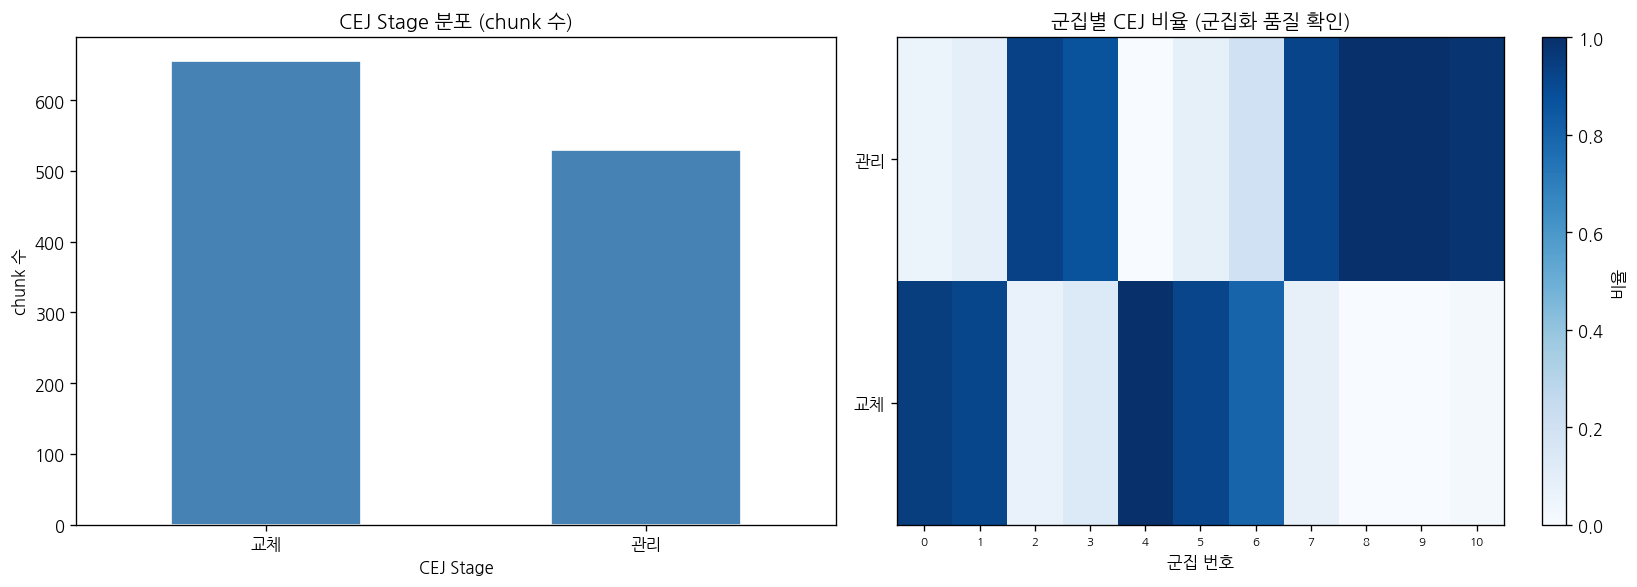


군집 순도 (지배적 CEJ 비율) 분포:
count    11.000
mean      0.934
std       0.063
min       0.797
25%       0.914
50%       0.933
75%       0.991
max       1.000
dtype: float64

순도 0.7 이상 군집: 11 / 11 개
순도 1.0 (단일 CEJ) 군집: 3 / 11 개


In [ ]:
# ── CEJ 분포 시각화 ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
fm.fontManager.__init__()
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) CEJ stage 분포 (chunk 수 기준)
clean_df["cej_primary"].value_counts().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("CEJ Stage 분포 (chunk 수)")
axes[0].set_xlabel("CEJ Stage")
axes[0].set_ylabel("chunk 수")
axes[0].tick_params(axis="x", rotation=0)

# (2) 군집별 CEJ 비율 히트맵 (군집화 품질 확인용)
import numpy as np
cross_ct = (
    clean_df.groupby(["cluster", "cej_primary"])
    .size()
    .unstack(fill_value=0)
)
# 행(군집) 기준 비율 정규화
cross_pct = cross_ct.div(cross_ct.sum(axis=1), axis=0)

im = axes[1].imshow(cross_pct.values.T, cmap="Blues", aspect="auto", vmin=0, vmax=1)
axes[1].set_xticks(range(len(cross_pct.index)))
axes[1].set_xticklabels(cross_pct.index, fontsize=7)
axes[1].set_yticks(range(len(cross_pct.columns)))
axes[1].set_yticklabels(cross_pct.columns)
axes[1].set_title("군집별 CEJ 비율 (군집화 품질 확인)")
axes[1].set_xlabel("군집 번호")
plt.colorbar(im, ax=axes[1], label="비율")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cej_distribution.png", dpi=150)
plt.show()

# 군집 순도 요약
purity = cross_pct.max(axis=1)
print("\n군집 순도 (지배적 CEJ 비율) 분포:")
print(purity.describe().round(3))
print(f"\n순도 0.7 이상 군집: {(purity >= 0.7).sum()} / {len(purity)} 개")
print(f"순도 1.0 (단일 CEJ) 군집: {(purity == 1.0).sum()} / {len(purity)} 개")

In [ ]:
# ── 군집별 요약 테이블 생성 ──────────────────────────────────────────────────
from collections import Counter

def get_keywords(df, cluster_id, top_n=5):
    sub = df[df["cluster"] == cluster_id]
    kws = sub["keyword"].dropna().str.split(",").explode().str.strip()
    return [k for k, _ in Counter(kws).most_common(top_n)]

def get_sample(df, cluster_id):
    sub = df[df["cluster"] == cluster_id]
    sub = sub[(sub["chunk_len"] >= 50) & (sub["chunk_len"] <= 300)]
    if sub.empty:
        sub = df[df["cluster"] == cluster_id]
    return sub["chunk_text"].iloc[0][:100] if len(sub) else ""

def get_dominant_cej(df, cluster_id):
    sub = df[df["cluster"] == cluster_id]
    vc = sub["cej_primary"].value_counts()
    if vc.empty:
        return "없음", 0.0
    dominant = vc.index[0]
    ratio = vc.iloc[0] / vc.sum()
    return dominant, round(ratio, 3)

cluster_ids = sorted(clean_df["cluster"].unique())
cluster_summary = []
for cid in cluster_ids:
    dominant_cej, purity = get_dominant_cej(clean_df, cid)
    cej_dist = clean_df[clean_df["cluster"] == cid]["cej_primary"].value_counts().to_dict()
    cluster_summary.append({
        "cluster":       cid,
        "size":          (clean_df["cluster"] == cid).sum(),
        "dominant_cej":  dominant_cej,
        "purity":        purity,
        "cej_분포":       str(cej_dist),
        "keywords":      str(get_keywords(clean_df, cid)),
        "sample_text":   get_sample(clean_df, cid),
    })

cluster_summary_df = pd.DataFrame(cluster_summary)
display(cluster_summary_df[["cluster", "size", "dominant_cej", "purity", "cej_분포", "keywords"]])

cluster_summary_df.to_csv(OUTPUT_DIR / "cluster_cej_summary.csv", index=False, encoding="utf-8-sig")
print("저장 완료: cluster_cej_summary.csv")
print("\n※ purity: 군집 내 지배적인 cej_stage 비율 (1.0 = 단일 CEJ로만 구성된 순수 군집)")

,cluster,size,dominant_cej,purity,cej_분포,keywords
0,0,57,교체,0.947,"{'교체': 54, '관리': 3}","['LG냉장고 교체', '엘지냉장고 AS', '냉장고 교체 후기']"
1,1,34,교체,0.912,"{'교체': 31, '관리': 3}","['LG냉장고 교체', 'LG냉장고 수리', '냉장고 교체 후기']"
2,2,45,관리,0.933,"{'관리': 42, '교체': 3}","['LG냉장고 수리', 'LG냉장고 고장', '엘지냉장고 AS', 'LG냉장고 교체']"
3,3,44,관리,0.864,"{'관리': 38, '교체': 6}","['LG냉장고 고장', 'LG냉장고 수리', '엘지냉장고 AS', 'LG냉장고 교체']"
4,4,39,교체,1.000,{'교체': 39},['냉장고 바꿨어요']
5,5,431,교체,0.916,"{'교체': 395, '관리': 36}","['냉장고 교체 후기', '냉장고 바꿨어요', 'LG냉장고 교체', 'LG냉장고 수리', '엘지냉장고 AS']"
6,6,143,교체,0.797,"{'교체': 114, '관리': 29}","['LG냉장고 교체', '엘지냉장고 AS', '냉장고 교체 후기', '냉장고 바꿨어요', 'LG냉장고 고장']"
7,7,150,관리,0.920,"{'관리': 138, '교체': 12}","['LG냉장고 고장', '엘지냉장고 AS', 'LG냉장고 수리', 'LG냉장고 교체', '냉장고 교체 후기']"
8,8,63,관리,1.000,{'관리': 63},"['엘지냉장고 AS', 'LG냉장고 고장', 'LG냉장고 수리']"
9,9,63,관리,1.000,{'관리': 63},"['LG냉장고 수리', '엘지냉장고 AS', 'LG냉장고 고장']"


저장 완료: cluster_cej_summary.csv

※ purity: 군집 내 지배적인 cej_stage 비율 (1.0 = 단일 CEJ로만 구성된 순수 군집)


In [ ]:
clean_df.to_csv(OUTPUT_DIR / "blog_clustered.csv", index=False, encoding="utf-8-sig")
print(f"저장 완료: blog_clustered.csv ({len(clean_df)} rows)")

## 이미지 군집화

In [ ]:
# ── matched_df에 군집 정보 연결 ──────────────────────────────────────────────
import pandas as pd

matched_df = pd.read_csv(OUTPUT_DIR / "blog_matched_pairs.csv", encoding="utf-8-sig")

# chunk_idx → cluster, cej_stage 매핑 (노이즈 군집 제외된 clean_df 기준)
chunk_to_cluster = clean_df["cluster"].to_dict()
chunk_to_cej     = clean_df["cej_stage"].to_dict()  # cej_stage 직접 사용

matched_df["cluster"]     = matched_df["chunk_idx"].map(chunk_to_cluster)
matched_df["cej_primary"] = matched_df["chunk_idx"].map(chunk_to_cej)

# 노이즈 군집(clean_df에 없는 chunk) 제거
matched_valid = matched_df[matched_df["cej_primary"].notna()].copy()
matched_valid["cluster"] = matched_valid["cluster"].astype(int)

print(f"전체 매칭 페어:        {len(matched_df)}")
print(f"CEJ 매핑된 페어:       {len(matched_valid)}")
print(f"\ncej_primary 분포:")
display(matched_valid["cej_primary"].value_counts())

전체 매칭 페어:        60325
CEJ 매핑된 페어:       4774

cej_primary 분포:


,count
cej_primary,
관리,2509
교체,2265


In [ ]:
cluster_label_map = {
    0:  "정수필터 교체 주기·방법",
    1:  "고무패킹 교체·불량 대응",
    2:  "냉장고 고장 불만·경험 공유",
    3:  "냉장고 셀프 점검·문제해결 팁",
    4:  "미니·레트로 냉장고 구매 후기",
    5:  "냉장고 신제품 구매·사용 일반 후기",
    6:  "냉장고 교체 결정·구매 고민",
    7:  "LG 냉장고 AS·수리 경험",
    8:  "LG 서비스센터 예약·접수 안내",
    9:  "업소용·전문 냉장고 수리",
    10: "냉장고 수리 반복·불량 대응",
}

In [ ]:
# =============================================================================
# 텍스트 군집별 이미지 HDBSCAN
# =============================================================================

from sklearn.preprocessing import normalize
import umap
import hdbscan

img_embs_all  = np.load(OUTPUT_DIR / "img_embs_all.npy")
img_valid_idx = np.load(OUTPUT_DIR / "img_valid_idx.npy").tolist()
img_pos_map   = {idx: pos for pos, idx in enumerate(img_valid_idx)}

print(f"전체 이미지 embedding 수: {len(img_valid_idx)}")

tc_img_cluster_results = {}  # tc → {df_img_idx: img_sub_cluster}

for tc in sorted(clean_df["cluster"].unique()):
    if tc == -1:
        continue

    tc_pairs       = matched_valid[matched_valid["cluster"] == tc]
    valid_img_idxs = [
        int(i) for i in tc_pairs["df_img_idx"].dropna().unique()
        if int(i) in img_pos_map
    ]

    print(f"\n=== TC {tc} ({cluster_label_map.get(tc, '')}) | 이미지 {len(valid_img_idxs)}장 ===")

    if len(valid_img_idxs) < 5:
        tc_img_cluster_results[tc] = {i: 0 for i in valid_img_idxs}
        print("  → 이미지 부족, 단일 군집 처리")
        continue

    X = normalize(
        np.vstack([img_embs_all[img_pos_map[i]] for i in valid_img_idxs]),
        norm="l2"
    )

    # UMAP
    n_neighbors = min(15, len(X) - 1)
    n_components = min(15, len(X) - 2)
    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=0.0,
        metric="cosine",
        random_state=42
    )
    X_umap = reducer.fit_transform(X)

    # HDBSCAN — 군집 수가 너무 많아지지 않도록 mcs는 이미지 수의 10%
    mcs    = max(5, len(X) // 10)
    labels = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=3,
        metric="euclidean",
        cluster_selection_method="eom"
    ).fit_predict(X_umap)

    vc     = pd.Series(labels).value_counts().sort_index()
    n_cl   = (vc.index != -1).sum()
    n_noise = int(vc.get(-1, 0))
    print(f"  → 군집 {n_cl}개 | noise {n_noise}개 | 분포: {vc.to_dict()}")

    tc_img_cluster_results[tc] = dict(zip(valid_img_idxs, labels))

print("\n\n전체 완료")
print(f"처리된 텍스트 군집 수: {len(tc_img_cluster_results)}")

전체 이미지 embedding 수: 4938

=== TC 0 (정수필터 교체 주기·방법) | 이미지 85장 ===
  → 군집 3개 | noise 4개 | 분포: {-1: 4, 0: 23, 1: 32, 2: 26}

=== TC 1 (고무패킹 교체·불량 대응) | 이미지 32장 ===
  → 군집 0개 | noise 32개 | 분포: {-1: 32}

=== TC 2 (냉장고 고장 불만·경험 공유) | 이미지 54장 ===
  → 군집 4개 | noise 2개 | 분포: {-1: 2, 0: 13, 1: 16, 2: 7, 3: 16}

=== TC 3 (냉장고 셀프 점검·문제해결 팁) | 이미지 66장 ===
  → 군집 5개 | noise 2개 | 분포: {-1: 2, 0: 16, 1: 8, 2: 13, 3: 11, 4: 16}

=== TC 4 (미니·레트로 냉장고 구매 후기) | 이미지 35장 ===
  → 군집 2개 | noise 0개 | 분포: {0: 26, 1: 9}

=== TC 5 (냉장고 신제품 구매·사용 일반 후기) | 이미지 605장 ===
  → 군집 5개 | noise 43개 | 분포: {-1: 43, 0: 64, 1: 129, 2: 110, 3: 78, 4: 181}

=== TC 6 (냉장고 교체 결정·구매 고민) | 이미지 250장 ===
  → 군집 4개 | noise 19개 | 분포: {-1: 19, 0: 57, 1: 32, 2: 51, 3: 91}

=== TC 7 (LG 냉장고 AS·수리 경험) | 이미지 299장 ===
  → 군집 4개 | noise 27개 | 분포: {-1: 27, 0: 104, 1: 51, 2: 57, 3: 60}

=== TC 8 (LG 서비스센터 예약·접수 안내) | 이미지 49장 ===
  → 군집 2개 | noise 0개 | 분포: {0: 18, 1: 31}

=== TC 9 (업소용·전문 냉장고 수리) | 이미지 191장 ===
  → 군집 5개 | noise 1개 | 분포: {-1: 1, 0

In [ ]:
# 기존 img_cluster 컬럼 대신 img_sub_cluster로 교체
def get_img_sub_cluster(row):
    tc      = row["cluster"]
    img_idx = int(row["df_img_idx"]) if pd.notna(row["df_img_idx"]) else -1
    if tc not in tc_img_cluster_results:
        return -1
    return tc_img_cluster_results[tc].get(img_idx, -1)

matched_valid["img_sub_cluster"] = matched_valid.apply(get_img_sub_cluster, axis=1)

print("img_sub_cluster 분포")
display(matched_valid.groupby(["cluster", "img_sub_cluster"]).size().reset_index(name="count").sort_values(["cluster","img_sub_cluster"]))

img_sub_cluster 분포


,cluster,img_sub_cluster,count
0,0,-1,12
1,0,0,62
2,0,1,82
3,0,2,61
4,1,-1,82
5,2,-1,5
6,2,0,37
7,2,1,40
8,2,2,21
9,2,3,37


In [ ]:
# ── [셀 38] 텍스트 군집 × 이미지 군집 교차 분석 ──────────────────────────────
cross = (
    matched_valid
    .groupby(["cluster", "img_sub_cluster"])  # img_cluster → img_sub_cluster
    .size()
    .reset_index(name="pair_count")
    .sort_values("pair_count", ascending=False)
)

print("텍스트 군집 × 이미지 하위 군집 상위 20 페어")
display(cross.head(20))
cross.to_csv(OUTPUT_DIR / "cluster_cross_analysis.csv", index=False, encoding="utf-8-sig")

텍스트 군집 × 이미지 군집 상위 20 페어


,cluster,img_cluster,pair_count
72,5,8,300
107,7,2,282
86,5,23,280
64,5,-1,169
65,5,0,160
162,10,2,159
104,6,23,154
124,7,23,128
67,5,2,116
81,5,18,109


In [ ]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import math

plt.rcParams["font.family"]        = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

def load_image(url, timeout=5):
    try:
        resp = requests.get(url, timeout=timeout)
        if resp.status_code == 200:
            return Image.open(BytesIO(resp.content)).convert("RGB")
    except:
        pass
    return None

def show_tc_img_clusters(tc, matched_valid, n_show=6, cols=3):
    tc_label = cluster_label_map.get(tc, f"TC{tc}")
    sub_clusters = sorted(
        matched_valid[matched_valid["cluster"] == tc]["img_sub_cluster"].unique()
    )

    for sc in sub_clusters:
        if sc == -1:
            continue
        sub = (
            matched_valid[
                (matched_valid["cluster"] == tc) &
                (matched_valid["img_sub_cluster"] == sc)
            ]
            .drop_duplicates("image_url")
            .sort_values("chunk_image_sim", ascending=False)
            .head(n_show)
        )
        if len(sub) == 0:
            continue

        rows = math.ceil(len(sub) / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
        axes = np.array(axes).reshape(-1)

        fig.suptitle(
            f"TC {tc} ({tc_label})  |  img_sub_cluster {sc}  (n={len(sub)})\n"
            f"대표텍스트: {sub['chunk_text'].iloc[0][:80]}",
            fontsize=9, ha="left", x=0.01
        )

        for ax, (_, r) in zip(axes, sub.iterrows()):
            img = load_image(r["image_url"])
            if img:
                ax.imshow(img); ax.axis("off")
                ax.set_title(f"sim={r['chunk_image_sim']:.2f}", fontsize=7)
            else:
                ax.axis("off"); ax.set_title("load err", fontsize=7)
        for ax in axes[len(sub):]:
            ax.axis("off")

        plt.tight_layout()
        save_path = OUTPUT_DIR / f"img_TC{tc}_SC{sc}.png"
        plt.savefig(save_path, dpi=100, bbox_inches="tight")
        plt.show()
        print(f"저장: {save_path}")

# 전체 텍스트 군집 순회
for tc in sorted(clean_df["cluster"].unique()):
    if tc == -1:
        continue
    print(f"\n{'='*60}")
    print(f"TC {tc} | {cluster_label_map.get(tc,'')}")
    show_tc_img_clusters(tc, matched_valid)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ── [셀 39] matched_valid 저장 ────────────────────────────────────────────────
matched_valid.to_csv(OUTPUT_DIR / "blog_matched_final.csv", index=False, encoding="utf-8-sig")
print(f"저장 완료: blog_matched_final.csv ({len(matched_valid)} rows)")

In [ ]:
# ── [셀 40] CEJ별 통계 요약 ───────────────────────────────────────────────────
cej_insight = (
    matched_valid
    .groupby("cej_primary")
    .agg(
        chunk_수=("chunk_idx", "nunique"),
        이미지_수=("df_img_idx", "nunique"),
        페어_수=("chunk_idx", "count"),
        평균_유사도=("chunk_image_sim", "mean"),
        최고_유사도=("chunk_image_sim", "max"),
    )
    .round(4)
    .reset_index()
)

print("CEJ별 텍스트-이미지 매칭 통계")
display(cej_insight)


CEJ별 텍스트-이미지 매칭 통계


,cej_primary,chunk_수,이미지_수,페어_수,평균_유사도,최고_유사도
0,관리,454,982,2509,0.3253,0.5979
1,교체,481,879,2265,0.3127,0.5641


In [ ]:
# Cell 58 교체 — clean_df 기준으로 대표 텍스트 생성
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# text_cluster_embs 재구성 (clean_df index 기준)
text_pos_map = {idx: pos for pos, idx in enumerate(text_valid_idx)}

cluster_emb_list = []
for idx in clean_df.index:
    if idx in text_pos_map:
        cluster_emb_list.append(text_embs[text_pos_map[idx]])
    else:
        cluster_emb_list.append(np.zeros(text_embs.shape[1], dtype=np.float32))

text_cluster_embs = np.vstack(cluster_emb_list)

# cluster_rep_df 생성
cluster_rep_rows = []
for cid in sorted(clean_df["cluster"].unique()):
    if cid == -1:
        continue
    mask    = (clean_df["cluster"] == cid).values
    idx_arr = np.where(mask)[0]
    embs    = text_cluster_embs[idx_arr]
    centroid = normalize(embs.mean(axis=0, keepdims=True), norm="l2")
    sims     = cosine_similarity(embs, centroid).flatten()
    top_n    = np.argsort(-sims)[:5]
    for rank, li in enumerate(top_n, 1):
        row = clean_df.iloc[idx_arr[li]]
        cluster_rep_rows.append({
            "text_cluster":  cid,
            "rank":          rank,
            "cluster_size":  int(mask.sum()),
            "centroid_sim":  float(sims[li]),
            "chunk_text":    row["chunk_text"],
            "cej_primary":   row["cej_stage"],
            "keyword":       row.get("keyword", ""),
        })

cluster_rep_df = pd.DataFrame(cluster_rep_rows)

# 대표 텍스트 출력
for cid in sorted(cluster_rep_df["text_cluster"].unique()):
    tmp = cluster_rep_df[cluster_rep_df["text_cluster"] == cid].sort_values("rank")
    cej = tmp["cej_primary"].value_counts().idxmax()
    size = tmp["cluster_size"].iloc[0]
    print("="*80)
    print(f"Cluster {cid} | size={size} | cej={cej}")
    for _, r in tmp.head(3).iterrows():
        print(f"  [{r['rank']}] {r['chunk_text'][:150]}")
    print()

Cluster 0 | size=57 | cej=교체
  [1] 모델별 정수필터 교체 주기, 정확히 알아보기
  [2] 정수필터, 반드시 주기적으로 교체해야 하는 이유
  [3] 필터 교체 작업 시 주의해야 할 핵심 요소

Cluster 1 | size=34 | cej=교체
  [1] 고무패킹 교체 시기와 자가 교체 가능성
  [2] (패킹이 안맞으면 냉장고를 교환해야 하는데..)
  [3] 고객센터 상담사의 안내에 따라 서비스센터를 통해 구매

Cluster 2 | size=45 | cej=관리
  [1] 산지 2년 7개월밖에 안지났다고?!!!
  [2] 냉장고의 냉기가 남아 있는 것 같아서
  [3] 이 글을 적는 이유도 누군가 나와 같은 문제가 발생했을 때

Cluster 3 | size=44 | cej=관리
  [1] (이때 체크하는 방법 참고해서 나중에
  [2] 도움 되셨다면 클릭하셔서 팬 하기 누르고 소식 더 편하게 받아보세요 :)
  [3] 이걸로 보통 90% 문제해결이 된다고 하시더라구요~

Cluster 4 | size=39 | cej=교체
  [1] 원룸에 딱 맞는 스타일리시한 냉장고가 필요했는데요. 아무튼 깔끔하면서도 빈티지 느낌 나는 게 갑자기 너무 끌려서 쿠잉 레트로 미니냉장고 REF-D85를 사게 됐어요. 생각보다 크기도 슬림하더라고요. 신혼집이나 사무실용으로도 좋은 크기에 디자인이 정말 예뻐서 한눈에 반했
  [2] 요즘 원룸 인테리어 바꾸면서 미니냉장고 필요했거든요. 근데 너무 평범한 건 싫고 분위기 있는 걸 원해서 이 쿠잉 레트로 미니냉장고에 꽂혔어요. 색감도 예쁘고 크기도 딱 적당해서 결정했는데 실제 써보니 더 만족스러웠답니다.
  [3] #쿠잉레트로냉장고#미니냉장고#원룸가전#신혼가전#소형냉장고#레트로인테리어#사무실냉장고

Cluster 5 | size=431 | cej=교체
  [1] 주방에서 가장 눈에 띄는 가전 중 하나인
  [2] [ 사진을 누르시면 번호로 이동됩니다 ]
  [3] 기능이 너무 너무 잘 되는 우리집 냉장고

In [ ]:
summary_rows = []

for tc in sorted(clean_df["cluster"].unique()):
    if tc == -1:
        continue

    tc_pairs = matched_valid[matched_valid["cluster"] == tc]

    for sc in sorted(tc_pairs["img_sub_cluster"].unique()):
        if sc == -1:
            continue

        sc_pairs = tc_pairs[tc_pairs["img_sub_cluster"] == sc]

        summary_rows.append({
            "TC":              tc,
            "텍스트_군집명":    cluster_label_map.get(tc, ""),
            "CEJ":             cluster_cej_map.get(tc, ""),
            "IMG_SC":          sc,
            "페어_수":          len(sc_pairs),
            "고유_이미지_수":   sc_pairs["df_img_idx"].nunique(),
            "평균_유사도":      round(sc_pairs["chunk_image_sim"].mean(), 3),
            "대표_텍스트":      sc_pairs["chunk_text"].iloc[0][:80],
            "이미지_라벨":      "",   # 이미지 보고 직접 작성
        })

summary_df = pd.DataFrame(summary_rows)

display(summary_df[[
    "TC", "텍스트_군집명", "CEJ", "IMG_SC",
    "페어_수", "고유_이미지_수", "평균_유사도", "대표_텍스트"
]])

summary_df.to_csv(OUTPUT_DIR / "tc_imgsc_summary.csv", index=False, encoding="utf-8-sig")

,TC,텍스트_군집명,CEJ,IMG_SC,페어_수,고유_이미지_수,평균_유사도,대표_텍스트
0,0,정수필터 교체 주기·방법,교체,0,62,23,0.329,"엘지냉장고 정수기 필터 교체 신청 방법, 내용 정리"
1,0,정수필터 교체 주기·방법,교체,1,82,32,0.318,"엘지냉장고 정수기 필터 교체 신청 방법, 내용 정리"
2,0,정수필터 교체 주기·방법,교체,2,61,26,0.293,"엘지냉장고 정수기 필터 교체 신청 방법, 내용 정리"
3,2,냉장고 고장 불만·경험 공유,관리,0,37,13,0.360,오신김에 다른 LG 가전 봐주실 것도 없는지
4,2,냉장고 고장 불만·경험 공유,관리,1,40,16,0.328,(위 파일은 냉장고 소리를 녹음해놓은 파일이다. 시끄러우니 주의!)
5,2,냉장고 고장 불만·경험 공유,관리,2,21,7,0.365,"[CF E]에러코드에 대해 검색을 하니,설명이 나왔다."
6,2,냉장고 고장 불만·경험 공유,관리,3,37,16,0.304,오신김에 다른 LG 가전 봐주실 것도 없는지
7,3,냉장고 셀프 점검·문제해결 팁,관리,0,44,16,0.325,LG 냉장고 소음으로 인한 수리 후기
8,3,냉장고 셀프 점검·문제해결 팁,관리,1,24,8,0.384,LG 냉장고 소음으로 인한 수리 후기
9,3,냉장고 셀프 점검·문제해결 팁,관리,2,35,13,0.340,끽끽..찍찍 거리는 소리가 나기 시작했어요.


In [ ]:
img_sub_label_map = {
    # TC 0 — 정수필터 교체 주기·방법
    (0, 0): "필터 교체 제품·박스샷",
    (0, 1): "필터 교체 작업 과정",
    (0, 2): "필터 설치 위치·냉장고 내부",

    # TC 2 — 냉장고 고장 불만·경험 공유
    (2, 0): "LG 가전 제품 전체샷",
    (2, 1): "냉장고 소음·이상 증상 현장",
    (2, 2): "에러코드·디스플레이 화면",
    (2, 3): "고장 관련 기타 이미지",

    # TC 3 — 냉장고 셀프 점검·문제해결 팁
    (3, 0): "수리 후기 관련 냉장고 외관",
    (3, 1): "소음 부품 점검 사진",
    (3, 2): "이상 소음 부위 클로즈업",
    (3, 3): "점검 과정 기타",
    (3, 4): "수리 전후 비교",

    # TC 4 — 미니·레트로 냉장고 구매 후기
    (4, 0): "미니냉장고 외관·인테리어 배치",
    (4, 1): "미니냉장고 내부·수납",

    # TC 5 — 냉장고 신제품 구매·사용 일반 후기
    (5, 0): "냉장고 문 수리·셀프 점검",
    (5, 1): "냉장고 문 불량 상태",
    (5, 2): "냉장고 문 수리 전후",
    (5, 3): "신제품 구매 고민·비교",
    (5, 4): "냉장고 문 부품·나사",

    # TC 6 — 냉장고 교체 결정·구매 고민
    (6, 0): "배송·설치 현장",
    (6, 1): "LG 패키지 할인·번들 제품",
    (6, 2): "냉장고 외관 디자인·색상",
    (6, 3): "얼음정수기 냉장고 기능샷",

    # TC 7 — LG 냉장고 AS·수리 경험
    (7, 0): "수리 전 고장 증상 현장",
    (7, 1): "수리 기사 방문·작업",
    (7, 2): "부품 교체 작업",
    (7, 3): "수리 후 결과",

    # TC 8 — LG 서비스센터 예약·접수 안내
    (8, 0): "서비스센터 안내·정보 캡처",
    (8, 1): "수리비용 조회·견적",

    # TC 9 — 업소용·전문 냉장고 수리
    (9, 0): "업소용 냉장고 브랜드 목록",
    (9, 1): "업소용 냉장고 수리 현장",
    (9, 2): "업소용 냉장고 외관",
    (9, 3): "수리 점포·업체 사진",
    (9, 4): "업소용 냉장고 수리 작업",

    # TC 10 — 냉장고 수리 반복·불량 대응
    (10, 0): "긴급 식품 꺼내기·이사 현장",
    (10, 1): "업소용·가정용 냉장고 장비",
}

# summary_df에 라벨 적용
summary_df["이미지_라벨"] = summary_df.apply(
    lambda r: img_sub_label_map.get((r["TC"], r["IMG_SC"]), "미라벨"),
    axis=1
)

# matched_valid에도 적용
matched_valid["img_sub_label"] = matched_valid.apply(
    lambda r: img_sub_label_map.get(
        (int(r["cluster"]), int(r["img_sub_cluster"])), "미라벨"
    ) if pd.notna(r["img_sub_cluster"]) else "미라벨",
    axis=1
)

display(summary_df[[
    "TC", "텍스트_군집명", "CEJ", "IMG_SC",
    "페어_수", "고유_이미지_수", "평균_유사도", "이미지_라벨"
]])

summary_df.to_csv(OUTPUT_DIR / "tc_imgsc_summary_labeled.csv", index=False, encoding="utf-8-sig")
print("저장 완료")

,TC,텍스트_군집명,CEJ,IMG_SC,페어_수,고유_이미지_수,평균_유사도,이미지_라벨
0,0,정수필터 교체 주기·방법,교체,0,62,23,0.329,필터 교체 제품·박스샷
1,0,정수필터 교체 주기·방법,교체,1,82,32,0.318,필터 교체 작업 과정
2,0,정수필터 교체 주기·방법,교체,2,61,26,0.293,필터 설치 위치·냉장고 내부
3,2,냉장고 고장 불만·경험 공유,관리,0,37,13,0.360,LG 가전 제품 전체샷
4,2,냉장고 고장 불만·경험 공유,관리,1,40,16,0.328,냉장고 소음·이상 증상 현장
5,2,냉장고 고장 불만·경험 공유,관리,2,21,7,0.365,에러코드·디스플레이 화면
6,2,냉장고 고장 불만·경험 공유,관리,3,37,16,0.304,고장 관련 기타 이미지
7,3,냉장고 셀프 점검·문제해결 팁,관리,0,44,16,0.325,수리 후기 관련 냉장고 외관
8,3,냉장고 셀프 점검·문제해결 팁,관리,1,24,8,0.384,소음 부품 점검 사진
9,3,냉장고 셀프 점검·문제해결 팁,관리,2,35,13,0.340,이상 소음 부위 클로즈업


저장 완료


In [ ]:
# 최종 패턴 카드 — TC + IMG_SC 조합별 한 줄 요약
pattern_card_df = summary_df.copy()
pattern_card_df["패턴_ID"] = pattern_card_df.apply(
    lambda r: f"P{r['TC']:02d}-{r['IMG_SC']}", axis=1
)
pattern_card_df["패턴명"] = pattern_card_df.apply(
    lambda r: f"{r['텍스트_군집명']} × {r['이미지_라벨']}", axis=1
)

display(pattern_card_df[[
    "패턴_ID", "패턴명", "CEJ",
    "페어_수", "평균_유사도", "대표_텍스트"
]])

pattern_card_df.to_csv(OUTPUT_DIR / "pattern_cards_final.csv", index=False, encoding="utf-8-sig")
print("저장 완료")

,패턴_ID,패턴명,CEJ,페어_수,평균_유사도,대표_텍스트
0,P00-0,정수필터 교체 주기·방법 × 필터 교체 제품·박스샷,교체,62,0.329,"엘지냉장고 정수기 필터 교체 신청 방법, 내용 정리"
1,P00-1,정수필터 교체 주기·방법 × 필터 교체 작업 과정,교체,82,0.318,"엘지냉장고 정수기 필터 교체 신청 방법, 내용 정리"
2,P00-2,정수필터 교체 주기·방법 × 필터 설치 위치·냉장고 내부,교체,61,0.293,"엘지냉장고 정수기 필터 교체 신청 방법, 내용 정리"
3,P02-0,냉장고 고장 불만·경험 공유 × LG 가전 제품 전체샷,관리,37,0.360,오신김에 다른 LG 가전 봐주실 것도 없는지
4,P02-1,냉장고 고장 불만·경험 공유 × 냉장고 소음·이상 증상 현장,관리,40,0.328,(위 파일은 냉장고 소리를 녹음해놓은 파일이다. 시끄러우니 주의!)
5,P02-2,냉장고 고장 불만·경험 공유 × 에러코드·디스플레이 화면,관리,21,0.365,"[CF E]에러코드에 대해 검색을 하니,설명이 나왔다."
6,P02-3,냉장고 고장 불만·경험 공유 × 고장 관련 기타 이미지,관리,37,0.304,오신김에 다른 LG 가전 봐주실 것도 없는지
7,P03-0,냉장고 셀프 점검·문제해결 팁 × 수리 후기 관련 냉장고 외관,관리,44,0.325,LG 냉장고 소음으로 인한 수리 후기
8,P03-1,냉장고 셀프 점검·문제해결 팁 × 소음 부품 점검 사진,관리,24,0.384,LG 냉장고 소음으로 인한 수리 후기
9,P03-2,냉장고 셀프 점검·문제해결 팁 × 이상 소음 부위 클로즈업,관리,35,0.340,끽끽..찍찍 거리는 소리가 나기 시작했어요.


저장 완료
